# Análise de Classificação de Popularidade Literária: Regressão Logística

Este notebook documenta o desenvolvimento, otimização e avaliação de um modelo estatístico linear probabilístico (Regressão Logística) para prever o potencial de popularidade de obras literárias com base em seus metadados de pré-lançamento. 

O objetivo principal desta etapa é estabelecer um **baseline linear robusto**. Diferente de modelos baseados em árvores ou abordagens de aprendizado profundo, a Regressão Logística oferece total transparência na interpretação dos coeficientes, permitindo isolar a contribuição estatística de cada atributo e garantindo a explicabilidade necessária para a validação metodológica do projeto.

## 1. Engenharia de Atributos, Preparação e Divisão dos Dados

Nesta fase inicial, os conjuntos de dados processados são carregados e unificados. Realizamos a engenharia de novas variáveis (*Feature Engineering*) para extrair sinais estatísticos relevantes, como a frequência histórica de publicações do autor e a padronização dos formatos físicos/digitais da obra.

Para mitigar o **Data Leakage** (vazamento de dados) e garantir a validade estatística da avaliação, adota-se um protocolo rigoroso:
1. **Divisão Estratificada (80/20):** Garante que a proporção das classes (Bestseller, Média Popularidade e Nicho) seja idêntica no treino e no teste.
2. **Padronização Escore-Z Isolada:** O cálculo de médias e desvios-padrão do `StandardScaler` é computado estritamente sobre o conjunto de treinamento, sendo apenas aplicado ao teste.

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Carga dos dados processados e cruzamento estrutural (Merge)
df_generos = pd.read_parquet('../data/processed/books_pivot_mapped.parquet')
df_original = pd.read_parquet('../data/processed/books_clean.parquet')

df_class = pd.merge(
    df_original[['title', 'author', 'bookformat', 'pages', 'totalratings']], 
    df_generos, 
    on=['title', 'author'], 
    how='inner'
)

# 1.1 Limpeza pós-merge: Remove as duplicatas da tabela da direita e renomeia as da esquerda
df_class = df_class.drop(columns=['pages_y', 'totalratings_y', 'rating'], errors='ignore')
df_class = df_class.rename(columns={'pages_x': 'pages', 'totalratings_x': 'totalratings'})

# 2. Definição da Variável Alvo (3 Classes de Popularidade)
def definir_tres_classes(ratings):
    if ratings >= 10000:
        return 1  # Bestseller
    elif ratings >= 1000:
        return 2  # Média Popularidade
    else:
        return 3  # Nicho
    
df_class['popularity_class'] = df_class['totalratings'].apply(definir_tres_classes)

# 3. Engenharia de Atributos (Feature Engineering)
# 3.1. Frequência do Autor (Mapeamento de histórico)
autor_frequencia = df_class['author'].value_counts()
df_class['author_frequency'] = df_class['author'].map(autor_frequencia)

# 3.2. Tratamento do Formato do Livro (Agrupamento e Dummies)
top_formatos = df_class['bookformat'].value_counts().index[:5]
df_class['format_grouped'] = df_class['bookformat'].apply(lambda x: x if x in top_formatos else 'Other')
df_formatos_encoded = pd.get_dummies(df_class['format_grouped'], prefix='format', drop_first=True)

# 4. Definição das variáveis macro-gênero mapeadas
macro_generos = [
    'Artes, Lazer e Estilo de Vida', 'Fantasia e Ficção Científica', 
    'Ficção Geral e Literatura', 'História e Biografia', 
    'Infantojuvenil e Quadrinhos', 'Mistério, Thriller e Terror', 
    'Não-Ficção e Autodesenvolvimento', 'Outros', 'Romance'
]

# Definição dos atributos e da variável-alvo
x = pd.concat([df_class[['pages', 'author_frequency']], df_formatos_encoded, df_class[macro_generos]], axis=1).astype(float)
y = df_class['popularity_class']

# Divisão estratficada para preservação da distribuição das classes
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

## 2. Padronização de Atributos e Prevenção de Data Leakage

A Regressão Logistíca calcula distâncias e otimiza uma função de perda que é diretamente afetada pela escala das variáveis. 

Para mitigar o **Data Leakage** (vazamento de dados), o ajuste do escore-Z (`StandardScaler`) é computado **estritamente sobre o conjunto de treino** (`fit_transform`). O conjunto de teste é apenas transformado (`transform`) utilizando as médias e desvios padrão calculados previamente na base de treino. Isso garante que informações do futuro (teste) não influenciem o aprendizado do modelo.

In [8]:
from sklearn.preprocessing import StandardScaler

# Inicialização do padronizador 
scaler = StandardScaler()

# Ajuste e transformação baseados exclusivamente no treino
x_train_scaled = scaler.fit_transform(x_train)

# Transformação do teste para simular o ambiente produtivo
x_test_scaled = scaler.transform(x_test)

print(f"Dimensões do Conjunto de Treino: {x_train_scaled.shape}")
print(f"Dimensões do Conjunto de Teste: {x_test_scaled.shape}")

Dimensões do Conjunto de Treino: (65604, 16)
Dimensões do Conjunto de Teste: (16402, 16)


## 3. Otimização de Hiperparâmetros e Tratamento de Desbalanceamento

Visando maximizar o poder de generalização do  modelo sem o descarte artifical de dados (comum em técnicas de subamostragem), o parãmetro `class-weight='balanced'`. Este método introduz uma **matriz de custo** na função de perda penalizando de forma inversamente proporcional a frequência das classes, forçando o algoritmo a aprender os padrões das categorias minoritárias.

A sintonia do hiperparâmetro de regularização inversa ($C$) é conduzida via `GridSearchCV` associada a uma validação cruzada em 5 folds ($k=5$). A métrica de otimização escolhida é o **F1-Macro**, ideal por ponderar o equilíbrio entre precisão e sensibilidade de forma justa entre todas as classes.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Definição do espaço de busca paramétrica
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

# Estruturação da validação cruzada com penalização de custo balanceada
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Execução da Otimização estatística
grid_lr.fit(x_train_scaled, y_train)

# Extração do estimador ótimo
melhor_lr = grid_lr.best_estimator_
print(f"Parâmetro ótimo de regularização inversa (C): {grid_lr.best_params_['C']}")

Parâmetro ótimo de regularização inversa (C): 1.0


## 4. Avaliação Metodológica do Desempenho

A validação final do classificador é realizada confrontando as previsões obtidas contra um conjunto de teste isolado. A avaliaç;ão baseia-se no tripé estatístico de classificação de dados não balanceados:

* **Precision (Precisão):** Capacidade do modelo de não classificar uma obra incorretamente.
* **Recall (Sensibilidade):** Capacidade de mapear a totalidade dos casos reais de uma classe.
* **F1-Score:** Média harmônica que penaliza desequilíbrios severos entre precisão e sensibilidade.

In [10]:
from sklearn.metrics import classification_report, accuracy_score

# Geração das predições estatísticas
previsoes_lr = melhor_lr.predict(x_test_scaled)

print("=======================================================================")
print("          RELATÓRIO DE DESEMPENHO - REGRESSÃO LOGÍSTICA                ")
print("=======================================================================")
print(f"Acurácia Global: {accuracy_score(y_test, previsoes_lr) * 100:.2f}%\n")
print(classification_report(y_test, previsoes_lr, target_names=['Bestseller', 'Média Popularidade', 'Nicho']))
print("=======================================================================")

          RELATÓRIO DE DESEMPENHO - REGRESSÃO LOGÍSTICA                
Acurácia Global: 61.44%

                    precision    recall  f1-score   support

        Bestseller       0.13      0.58      0.21       731
Média Popularidade       0.32      0.40      0.36      3299
             Nicho       0.92      0.67      0.78     12372

          accuracy                           0.61     16402
         macro avg       0.46      0.55      0.45     16402
      weighted avg       0.76      0.61      0.67     16402



## 4.1. Análise Visual de Erros (Matriz de Confusão)

A matriz de confusão quantifica de forma cruzada as classificações exatas (diagonal principal) e os desvios cometidos pelo estimador. Essa análise permite diagnosticar se as falhas do modelo ocorrem por proximidade conceitual (ex: classificar um Bestseller como Média Popularidade) ou por erros severos de fronteira linear.



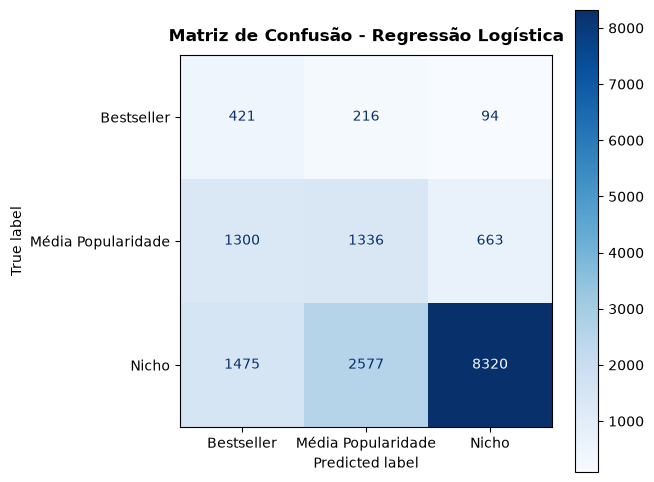

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Computação da matriz de erros
cm = confusion_matrix(y_test, previsoes_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bestseller', 'Média Popularidade', 'Nicho'])

# Renderização do mapa de calor
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusão - Regressão Logística", fontsize=12, fontweight='bold', pad=10)
plt.grid(False)
plt.show()

## 5. Análise de Coeficientes e Significância das Variáveis

Como as variáveis de entrada foram previamente submetidas à padronização escore-Z, a magnitude dos coeficientes finais da Regressão Logística torna-se diretamente comparável.

* **Coeficientes Positivos (Barras Azuis):** Indicam atributos que elevam significativamente a probabilidade de a obra pertencer à classe analisada (fatores de propensão).
* **Coeficientes Negativos (Barras Vermelhas):** Apontam para atributos que reduzem a probabilidade da obra atingir o respectivo nível de popularidade (fatores de mitigação).

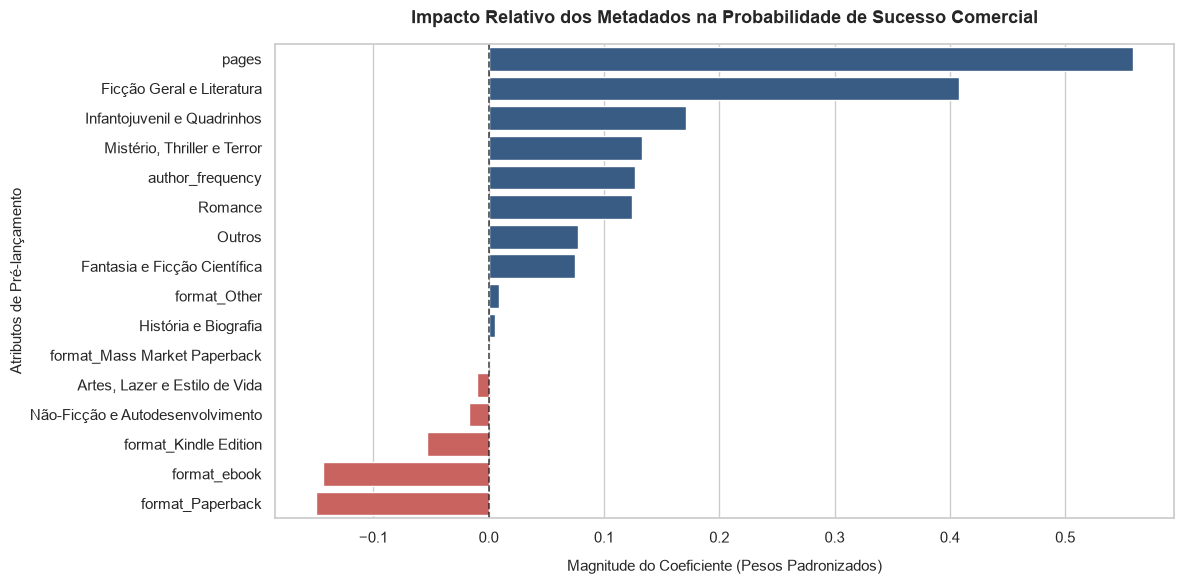

In [13]:
import seaborn as sns

# Extração dos pesos da classe de interesse (Classe 1 - Bestsellers)
coeficientes_classe1 = melhor_lr.coef_[0]

# Estruturação da tabela descritiva de impactos
df_coeficientes = pd.DataFrame({
    'Atributo': x_train.columns,
    'Coeficiente (Peso)': coeficientes_classe1
}).sort_values(by='Coeficiente (Peso)', ascending=False)

# Mapeamento cromático condicional à direção do impacto
df_coeficientes['Direcao_Cor'] = np.where(df_coeficientes['Coeficiente (Peso)'] >= 0, '#2b5c8f', '#d9534f')

# Construção do gráfico de relevância de atributos
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Coeficiente (Peso)', 
    y='Atributo', 
    hue='Atributo',
    legend=False,
    data=df_coeficientes, 
    palette=df_coeficientes['Direcao_Cor'].tolist()
)

plt.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.title('Impacto Relativo dos Metadados na Probabilidade de Sucesso Comercial', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Magnitude do Coeficiente (Pesos Padronizados)', fontsize=11, labelpad=10)
plt.ylabel('Atributos de Pré-lançamento', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Exportação do Estimador

Validada a consistência estatística do baseline, o modelo otimizado e calibrado é persistido em formato binário (.pkl) utilizando a biblioteca `joblib`. Esse procedimento assegura a reprodutibilidade dos resultados e possibilita a integração direta do artefato matemático com o ambiente de produção da aplicação final.

In [14]:
import joblib
import os

# Estruturação do repositório físico de persistência
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Machine Learning", "models"))
os.makedirs(models_dir, exist_ok=True)

# Exportação do modelo serializado
joblib.dump(melhor_lr, os.path.join(models_dir, "lr_popularidade.pkl"))
print("Modelo de Regressão Logística persistido com sucesso para a produção do App!")

Modelo de Regressão Logística persistido com sucesso para a produção do App!
